# **Notebook 4a: Training augmented version of feature based classifier for automatic weak labeling**


## 1. Importing the packages

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import json, zipfile
from google.colab import files

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working dir: /content/drive/MyDrive/Individual thesis part/Model 2: Feature based


## 2. Preparation

In [ ]:
# Paths
FEATURES_TRAIN = "./Data_with_features/features_train.csv"
FEATURES_VAL   = "./Data_with_features/features_val.csv"

# Column names
LABEL_COL = "unnecessary"
ID_COLS = ["blurb_id", "blurb_sent"]
EXCLUDE = ID_COLS + [LABEL_COL]

# Color scheme for in figures: red = unnecessary (positive class, to detect), green = necessary (keep)
COLOR_UNNEC = "#d62728"  # red
COLOR_NEC   = "#2ca02c"  # green

RANDOM_STATE = 222

## 3. Loading the data

In [ ]:
df_train = pd.read_csv(FEATURES_TRAIN)
print(f"Train: {df_train.shape[0]} rows × {df_train.shape[1]} cols")
df_val = pd.read_csv(FEATURES_VAL)
print(f"Val: {df_val.shape[0]} rows × {df_val.shape[1]} cols")

# Feature columns
feature_cols = [c for c in df_train.columns if c not in EXCLUDE]

# Labels
X_train = df_train[feature_cols].copy()
y_train = df_train[LABEL_COL].astype(int).copy()
X_val = df_val[feature_cols].copy()
y_val = df_val[LABEL_COL].astype(int).copy()

print(f"\nTrain label distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nVal label distribution:")
print(y_val.value_counts(normalize=True).round(3))

# Dropping features that are constant in the train dataset (they give no signal to the model)
stds = X_train.std()
constant_cols = stds[stds == 0].index.tolist()
if constant_cols:
    print(f"\nDropping constant features (std=0 on train): {constant_cols}")
    X_train = X_train.drop(columns=constant_cols)
    X_val = X_val.drop(columns=constant_cols)
    feature_cols = [c for c in feature_cols if c not in constant_cols]

print(f"\nFinal feature set: {len(feature_cols)} features")

Train: 1104 rows × 62 cols
Val: 302 rows × 62 cols

Train label distribution:
unnecessary
0    0.715
1    0.285
Name: proportion, dtype: float64

Val label distribution:
unnecessary
0    0.735
1    0.265
Name: proportion, dtype: float64

Dropping constant features (std=0 on train): ['ends_with_dash', 'n_misc']

Final feature set: 57 features


## 4. Exploratory analysis

### 4a. Per-class means: which features differ between classes?

In [ ]:
# Calculating means and differences between classes
rows = []
for col in feature_cols:
    m_remove = X_train.loc[y_train == 1, col].mean()
    m_keep   = X_train.loc[y_train == 0, col].mean()
    rows.append({
        "feature":     col,
        "mean_label_1": m_remove,
        "mean_label_0":   m_keep,
        "diff":        m_remove - m_keep,
        "abs_diff":    abs(m_remove - m_keep),
        "direction":   "higher  = remove" if m_remove > m_keep else "higher = keep",})

means_df = pd.DataFrame(rows).sort_values("abs_diff", ascending=False).reset_index(drop=True)
means_df = means_df.drop(columns=["abs_diff"])

# Printing top features with the highest differences between features (and thus likely the clearest patterns)
print("Top 10 features by absolute mean difference between classes (train):\n")
print(means_df.head(10).to_string(index=False))

Top 10 features by absolute mean difference between classes (train):

                feature  mean_label_1  mean_label_0       diff        direction
             char_count     85.806349    104.134347 -18.327998    higher = keep
          sent_position      8.260317      3.940431   4.319887 higher  = remove
             word_count     13.596825     16.958175  -3.361350    higher = keep
         n_tokens_spacy     15.819048     19.032953  -3.213905    higher = keep
word_count_rel_to_blurb     -1.514582      0.604681  -2.119262    higher = keep
        n_bertje_tokens     23.041270     24.965779  -1.924510    higher = keep
                 n_verb      1.279365      1.974651  -0.695286    higher = keep
                 n_pron      0.911111      1.594423  -0.683312    higher = keep
                 n_noun      2.793651      3.430925  -0.637274    higher = keep
                  n_adv      0.603175      1.115336  -0.512161    higher = keep


### 4b. Per-feature predictive power (univariate AUC op train)

In [ ]:
# Calculating predictive power
auc_rows = []
for col in feature_cols:
    x = X_train[col].values
    if np.std(x) == 0:
        auc_rows.append({"feature": col, "auc": 0.5, "direction": "none"})
        continue
    auc_pos = roc_auc_score(y_train, x)
    if auc_pos >= 0.5:
        auc_rows.append({"feature": col, "auc": auc_pos,     "direction": "higher = remove"})
    else:
        auc_rows.append({"feature": col, "auc": 1 - auc_pos, "direction": "higher = keep"})

auc_df = pd.DataFrame(auc_rows).sort_values("auc", ascending=False).reset_index(drop=True)

print("Top 20 features by univariate AUC (train):\n")
print(auc_df.head(20).to_string(index=False))
print(f"\nFeatures with AUC ≥ 0.60: {(auc_df['auc'] >= 0.60).sum()}")
print(f"Features with AUC ≥ 0.65: {(auc_df['auc'] >= 0.65).sum()}")
print(f"Features with AUC ≥ 0.70: {(auc_df['auc'] >= 0.70).sum()}")

Top 20 features by univariate AUC (train):

                  feature      auc       direction
            sent_position 0.752976 higher = remove
             rel_position 0.691546 higher = remove
  word_overlap_final_edit 0.667403   higher = keep
        sim_to_final_edit 0.660728   higher = keep
                   n_pron 0.645078   higher = keep
                   n_verb 0.640119   higher = keep
     sim_to_rest_of_blurb 0.634490   higher = keep
                    n_adv 0.621395   higher = keep
             verb_density 0.618563   higher = keep
               word_count 0.614169   higher = keep
verb_density_rel_to_blurb 0.599998   higher = keep
           n_tokens_spacy 0.599268   higher = keep
               char_count 0.596717   higher = keep
             avg_word_len 0.586527 higher = remove
                   n_noun 0.579108   higher = keep
  word_count_rel_to_blurb 0.578220   higher = keep
                  is_last 0.568954 higher = remove
                    n_org 0.562072 hig

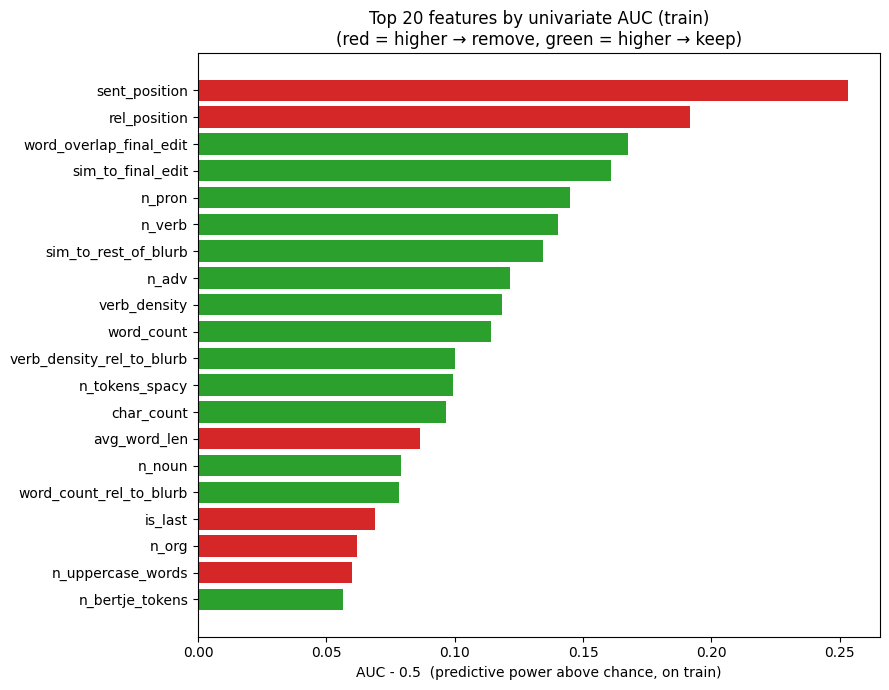

In [ ]:
top_n = 20
top = auc_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [COLOR_UNNEC if d == 'higher = remove' else COLOR_NEC for d in top['direction']]
ax.barh(range(len(top)), top['auc'] - 0.5, color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['feature'])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel("AUC - 0.5  (predictive power above chance, on train)")
ax.set_title(f"Top {top_n} features by univariate AUC (train)\n(red = higher → remove, green = higher → keep)")
plt.tight_layout()
plt.show()

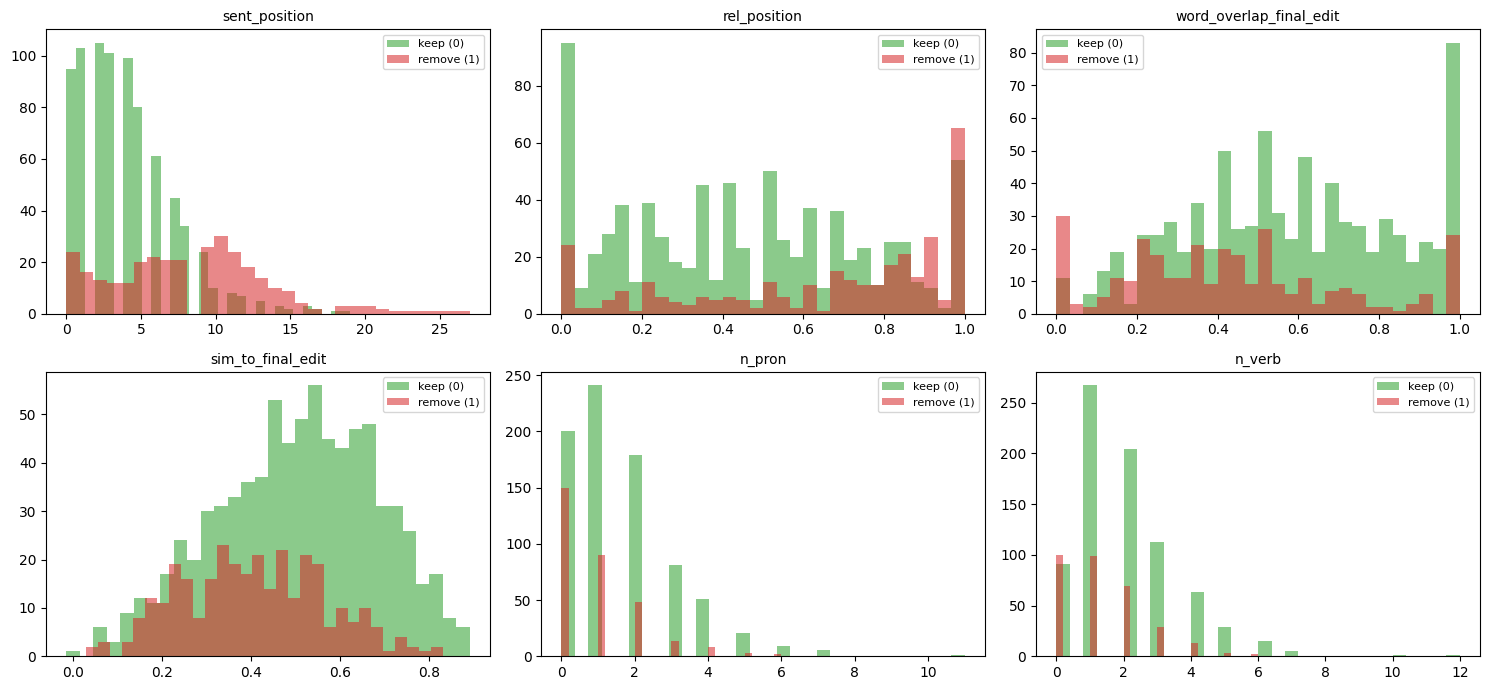

In [ ]:
# Top features by AUC
top_feats = auc_df.head(6)["feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.ravel(), top_feats):
    ax.hist(X_train.loc[y_train == 0, feat], bins=30, alpha=0.55, color=COLOR_NEC,   label="keep (0)")
    ax.hist(X_train.loc[y_train == 1, feat], bins=30, alpha=0.55, color=COLOR_UNNEC, label="remove (1)")
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

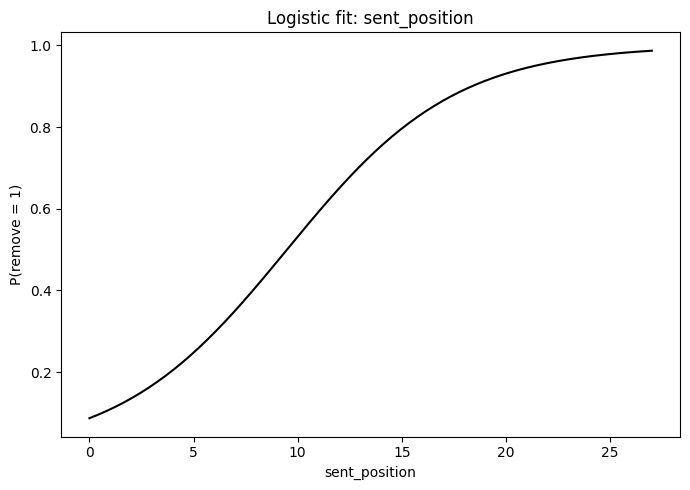

In [ ]:
# Logistic fit by sent_position
feat = auc_df.iloc[0]["feature"]
x = X_train[[feat]].to_numpy()

lr1d = LogisticRegression(max_iter=1000).fit(x, y_train)
xs = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(xs, lr1d.predict_proba(xs)[:, 1], color="black")
ax.set_xlabel(feat)
ax.set_ylabel("P(remove = 1)")
ax.set_title(f"Logistic fit: {feat}")
plt.tight_layout()
plt.show()

## 5. Fitting L1-regularized Logistic Regression

In [ ]:
# Scaling the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Different C values to test (higher C is less regularization)
C_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

lr1_results = []
print(f"{'C':>6}  {'n_features':>10}  {'train AUC':>10}  {'val AUC':>10}")
print("-" * 45)

# Initializing Logistic Regression with L1 regularization (Lasso)
for C in C_values:
    lr_labeling = LogisticRegression(
        penalty='l1',
        C=C,
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=2000,)

    # Training the labeling model on scaled training features
    lr_labeling.fit(X_train_scaled, y_train)

    # Extracting coefficients; L1 penalty forces less important feature coefficients to exactly 0
    coefs = lr_labeling.coef_[0]
    n_nonzero = (coefs != 0).sum()

    # Evaluating model performance using ROC-AUC based on the predicted probability of class 1
    train_auc = roc_auc_score(y_train, lr_labeling.predict_proba(X_train_scaled)[:, 1])
    val_auc   = roc_auc_score(y_val,   lr_labeling.predict_proba(X_val_scaled)[:, 1])

    # Storing results under the new model name
    lr1_results.append({
        "C": C,
        "n_features_used": n_nonzero,
        "train_auc": train_auc,
        "val_auc": val_auc,
        "model": lr_labeling,
        "coefs": coefs,})

    # Printing results
    print(f"{C:>6.2f}  {n_nonzero:>10d}  {train_auc:>10.3f}  {val_auc:>10.3f}")

     C  n_features   train AUC     val AUC
---------------------------------------------
  0.01           5       0.787       0.720
  0.05          19       0.868       0.844
  0.10          27       0.875       0.855
  0.20          39       0.880       0.860
  0.30          43       0.884       0.865
  0.40          46       0.886       0.868
  0.50          49       0.887       0.870
  0.60          51       0.888       0.871
  0.70          51       0.889       0.871
  0.80          52       0.889       0.871
  0.90          52       0.889       0.871
  1.00          52       0.889       0.871


In [ ]:
# Getting model parts with chosen c
CHOSEN_C = 0.50 # Chosen because of balance between amount of variables and validation auc score
chosen_result = [r for r in lr1_results if r["C"] == CHOSEN_C][0]
best_lr_labeling = chosen_result["model"]
scaler_lr1 = scaler  # sla scaler op onder duidelijke naam

## 6. Saving the model

In [ ]:
zip_path = "/content/model_labeling.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    # Save model
    joblib.dump(best_lr_labeling, "/content/lr1_labeling_model.joblib")
    zf.write("/content/lr1_labeling_model.joblib", arcname="lr1_labeling_model.joblib")

    # Save scaler
    joblib.dump(scaler, "/content/lr1_scaler.joblib")
    zf.write("/content/lr1_scaler.joblib", arcname="lr1_scaler.joblib")

    # Save feature columns
    with open("/content/lr1_feature_cols.json", "w") as f:
        json.dump(feature_cols, f)
    zf.write("/content/lr1_feature_cols.json", arcname="lr1_feature_cols.json")

print(f"Zip size: {os.path.getsize(zip_path) / 1024:.1f} KB")
files.download(zip_path)

Zip size: 4.0 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>